# 📊 TCC — Análise de Sentimento no Mercado Financeiro Brasileiro
## FASE 1 — Coleta e Preparação dos Dados

**Autor:** Yago de Azevedo Gomes  
**Curso:** MBA em Inteligência Artificial e Big Data — USP  
**Objetivo desta fase:**
- ✅ Instalar dependências
- ✅ Baixar e explorar o dataset de sentimento financeiro em português (lucas-leme/Sentiments-FinBERT-PT-BR)
- ✅ Coletar séries históricas do Ibovespa, Selic e câmbio BRL/USD
- ✅ Coletar Google Trends para termos financeiros brasileiros
- ✅ Gerar estatísticas descritivas e visualizações iniciais
- ✅ Salvar todos os dados processados para uso nas fases seguintes

---
## 📦 BLOCO 1 — Instalação das Dependências

In [25]:
# ── Monta Google Drive e configura pasta do TCC ──
from google.colab import drive
drive.mount('/content/drive')

import os

# Pasta permanente no seu Drive
PASTA_DRIVE = '/content/drive/MyDrive/TCC_dados'
os.makedirs(PASTA_DRIVE, exist_ok=True)

# Cria atalho local 'dados_tcc' apontando para o Drive
if os.path.islink('dados_tcc'):
    os.unlink('dados_tcc')
if not os.path.exists('dados_tcc'):
    os.symlink(PASTA_DRIVE, 'dados_tcc')

print(f'✅ Drive montado! Pasta: {PASTA_DRIVE}')
print(f'✅ Atalho local "dados_tcc" → {PASTA_DRIVE}')

Mounted at /content/drive
✅ Drive montado! Pasta: /content/drive/MyDrive/TCC_dados
✅ Atalho local "dados_tcc" → /content/drive/MyDrive/TCC_dados


In [26]:
# Instala todas as bibliotecas necessárias para a Fase 1
# Execute este bloco uma única vez no início da sessão

!pip install -q datasets yfinance pytrends pandas matplotlib seaborn transformers requests

print('✅ Todas as dependências instaladas com sucesso!')

✅ Todas as dependências instaladas com sucesso!


In [27]:
# Importações gerais utilizadas ao longo de toda a Fase 1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Configuração visual padrão para todos os gráficos do TCC
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

# Diretório para salvar os dados coletados
os.makedirs('dados_tcc', exist_ok=True)

print('✅ Importações concluídas!')

✅ Importações concluídas!


---
## 📚 BLOCO 2 — Dataset de Sentimento Financeiro em Português
### lucas-leme/Sentiments-FinBERT-PT-BR (HuggingFace)

Este dataset contém textos financeiros em português já anotados com polaridade:
- **Negativo**
- **Neutro**
- **Positivo**
- **Não se aplica**

> ⚠️ **Nota:** O dataset usa labels em string (não inteiros). O código abaixo já está adaptado para esse formato.

In [28]:
from datasets import load_dataset

print('⏳ Baixando dataset lucas-leme/Sentiments-FinBERT-PT-BR...')
print(' (Pode levar alguns segundos na primeira execução)\n')

# Carrega o dataset do HuggingFace
dataset = load_dataset('lucas-leme/Sentiments-FinBERT-PT-BR')

print('✅ Dataset carregado!')
print('\n📋 Estrutura do dataset:')
print(dataset)

⏳ Baixando dataset lucas-leme/Sentiments-FinBERT-PT-BR...
 (Pode levar alguns segundos na primeira execução)

✅ Dataset carregado!

📋 Estrutura do dataset:
DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'text', 'sentiment'],
        num_rows: 661
    })
})


In [29]:
# Converte para DataFrame para facilitar a análise

splits_disponiveis = list(dataset.keys())
print(f'Splits disponíveis: {splits_disponiveis}')

split_principal = 'train' if 'train' in splits_disponiveis else splits_disponiveis[0]
df_sentimento = dataset[split_principal].to_pandas()

print(f'\n✅ Split usado: "{split_principal}"')
print(f'Total de registros: {len(df_sentimento):,}')
print(f'\nColunas disponíveis: {list(df_sentimento.columns)}')
print('\n📝 Primeiros 5 registros:')
df_sentimento.head()

Splits disponíveis: ['train']

✅ Split usado: "train"
Total de registros: 661

Colunas disponíveis: ['Unnamed: 0', 'text', 'sentiment']

📝 Primeiros 5 registros:


,Unnamed: 0,text,sentiment
0,0,O aumento de preços do etanol em novembro deco...,Negativo
1,1,"RIO – A Transpetro recebe segunda-feira, no Es...",Positivo
2,2,"Como uma empresa autônoma, a Sylvamo terá maio...",Positivo
3,3,"Montagnier, que tinha 89 anos, ganhou o Prêmio...",Não se aplica
4,4,Curtas,Não se aplica


In [30]:
# Identifica a coluna de texto e a coluna de label
# O dataset pode ter nomes de colunas diferentes — este código se adapta automaticamente

colunas = list(df_sentimento.columns)

# Detecta coluna de texto
col_texto = None
for candidato in ['sentence', 'text', 'texto', 'content', 'headline', 'news']:
    if candidato in colunas:
        col_texto = candidato
        break
if col_texto is None:
    col_texto = colunas[0]

# Detecta coluna de label
col_label = None
for candidato in ['label', 'sentiment', 'sentimento', 'class', 'polaridade']:
    if candidato in colunas:
        col_label = candidato
        break
if col_label is None:
    col_label = colunas[-1]

print(f'Coluna de texto detectada: "{col_texto}"')
print(f'Coluna de label detectada: "{col_label}"')
print(f'\nValores únicos de label: {sorted(df_sentimento[col_label].unique())}')

Coluna de texto detectada: "text"
Coluna de label detectada: "sentiment"

Valores únicos de label: ['Negativo', 'Neutro', 'Não se aplica', 'Positivo']


In [31]:
# Padroniza o dataset
# CORREÇÃO: este dataset usa strings diretas como label (não inteiros)
# Classes encontradas: 'Positivo', 'Negativo', 'Neutro', 'Não se aplica'

df_sentimento['texto'] = df_sentimento[col_texto].astype(str)
df_sentimento['sentimento'] = df_sentimento[col_label].astype(str)

# Mapeamento de string para inteiro (para uso em modelos)
mapa_para_int = {
    'Negativo': 0,
    'Neutro': 1,
    'Positivo': 2,
    'Não se aplica': 3
}
df_sentimento['label_num'] = df_sentimento['sentimento'].map(mapa_para_int).fillna(3).astype(int)

print('✅ Dataset padronizado!')
print('\n📊 Distribuição de sentimentos:')
print(df_sentimento['sentimento'].value_counts())
print(f'\nTotal: {len(df_sentimento):,} registros')

✅ Dataset padronizado!

📊 Distribuição de sentimentos:
sentimento
Negativo         203
Positivo         160
Não se aplica    158
Neutro           140
Name: count, dtype: int64

Total: 661 registros


In [32]:
# ESTATÍSTICAS DESCRITIVAS DO DATASET DE SENTIMENTO

df_sentimento['num_palavras'] = df_sentimento['texto'].apply(lambda x: len(x.split()))
df_sentimento['num_chars'] = df_sentimento['texto'].apply(len)

print('=' * 55)
print(' ESTATÍSTICAS DO CORPUS DE SENTIMENTO FINANCEIRO')
print('=' * 55)
print(f'Total de textos: {len(df_sentimento):>8,}')
print(f'Média de palavras/texto: {df_sentimento["num_palavras"].mean():>8.1f}')
print(f'Mediana de palavras: {df_sentimento["num_palavras"].median():>8.1f}')
print(f'Texto mais curto (chars): {df_sentimento["num_chars"].min():>8,}')
print(f'Texto mais longo (chars): {df_sentimento["num_chars"].max():>8,}')
print('-' * 55)
print('\nDistribuição por classe:')
dist = df_sentimento['sentimento'].value_counts()
for classe, n in dist.items():
    pct = n / len(df_sentimento) * 100
    barra = '█' * int(pct / 2)
    print(f'  {classe:<15} {n:>5,} ({pct:4.1f}%) {barra}')
print('=' * 55)

 ESTATÍSTICAS DO CORPUS DE SENTIMENTO FINANCEIRO
Total de textos:      661
Média de palavras/texto:     35.7
Mediana de palavras:     36.0
Texto mais curto (chars):        4
Texto mais longo (chars):      510
-------------------------------------------------------

Distribuição por classe:
  Negativo          203 (30.7%) ███████████████
  Positivo          160 (24.2%) ████████████
  Não se aplica     158 (23.9%) ███████████
  Neutro            140 (21.2%) ██████████


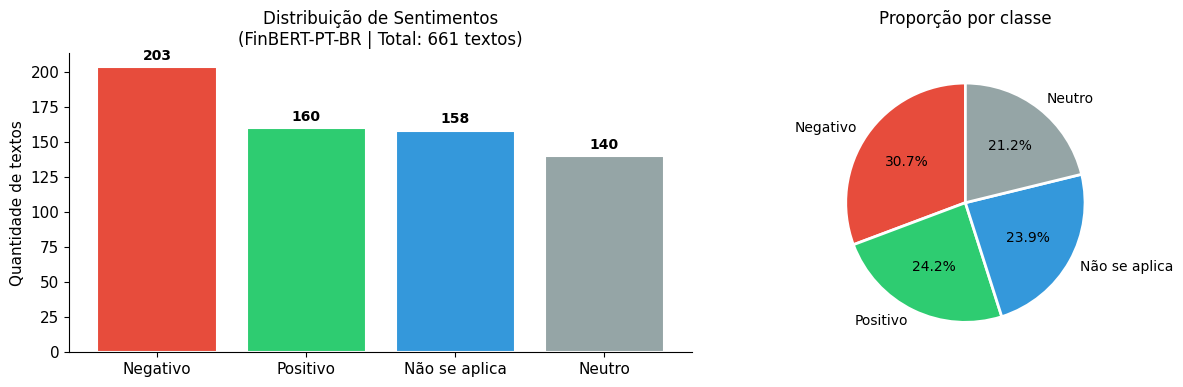

✅ Figura salva em dados_tcc/fig1_distribuicao_sentimentos.png


In [33]:
# VISUALIZAÇÃO 1 — Distribuição de sentimentos

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cores = {
    'Positivo': '#2ecc71',
    'Neutro': '#95a5a6',
    'Negativo': '#e74c3c',
    'Não se aplica': '#3498db'
}
contagens = df_sentimento['sentimento'].value_counts()
cores_ordenadas = [cores.get(s, '#bdc3c7') for s in contagens.index]

# Gráfico de barras
axes[0].bar(contagens.index, contagens.values, color=cores_ordenadas, edgecolor='white', linewidth=1.5)
axes[0].set_title(f'Distribuição de Sentimentos\n(FinBERT-PT-BR | Total: {len(df_sentimento):,} textos)', fontsize=12)
axes[0].set_ylabel('Quantidade de textos')
for i, (idx, val) in enumerate(contagens.items()):
    axes[0].text(i, val + 3, f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Pizza
axes[1].pie(
    contagens.values,
    labels=contagens.index,
    colors=cores_ordenadas,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 10}
)
axes[1].set_title('Proporção por classe\n', fontsize=12)

plt.tight_layout()
plt.savefig('dados_tcc/fig1_distribuicao_sentimentos.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figura salva em dados_tcc/fig1_distribuicao_sentimentos.png')

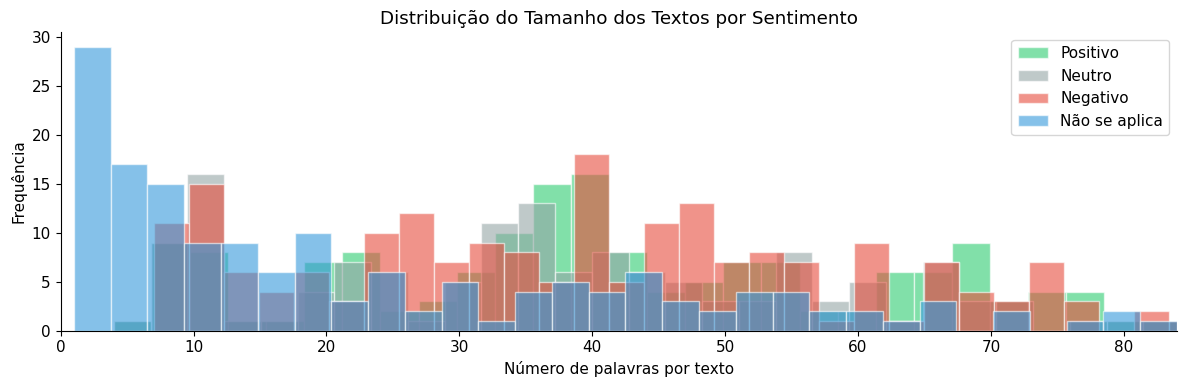

✅ Figura salva!


In [34]:
# VISUALIZAÇÃO 2 — Distribuição do comprimento dos textos por sentimento

fig, ax = plt.subplots(figsize=(12, 4))

for sentimento, cor in cores.items():
    subset = df_sentimento[df_sentimento['sentimento'] == sentimento]['num_palavras']
    if len(subset) > 0:
        ax.hist(subset, bins=30, alpha=0.6, label=sentimento, color=cor, edgecolor='white')

ax.set_xlabel('Número de palavras por texto')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição do Tamanho dos Textos por Sentimento')
ax.legend()
ax.set_xlim(0, df_sentimento['num_palavras'].quantile(0.99))

plt.tight_layout()
plt.savefig('dados_tcc/fig2_tamanho_textos.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figura salva!')

In [35]:
# Exibe exemplos de textos de cada classe — útil para análise qualitativa no TCC

print('=' * 65)
print('EXEMPLOS DE TEXTOS POR CLASSE DE SENTIMENTO')
print('=' * 65)

for sentimento in ['Positivo', 'Neutro', 'Negativo', 'Não se aplica']:
    subset = df_sentimento[df_sentimento['sentimento'] == sentimento]
    if len(subset) > 0:
        print(f'\n🔹 {sentimento.upper()} (3 exemplos):')
        amostras = subset['texto'].sample(min(3, len(subset)), random_state=42)
        for i, texto in enumerate(amostras, 1):
            print(f'  [{i}] {texto[:200]}...' if len(texto) > 200 else f'  [{i}] {texto}')

print('\n' + '=' * 65)

EXEMPLOS DE TEXTOS POR CLASSE DE SENTIMENTO

🔹 POSITIVO (3 exemplos):
  [1] A Cambuci teve lucro líquido de 4,7 milhões de reais no primeiro trimestre de 2013, alta de mais de 300 por cento frente ao mesmo período do ano anterior, quando o lucro líquido foi de 1,1 milhão de r...
  [2] CBO prevê faturamento de US$ 250 milhões em 2014
  [3] Bancos da Irlanda têm agora cerca de € 100 bilhões de liquidez fornecida pelo BCE. Para as instituições portuguesas, o total até agosto foi de € 46 bilhões,€ 2 bilhões a mais do que em julho. Mas isso...

🔹 NEUTRO (3 exemplos):
  [1] De acordo com o site Alexa, o UOL é quinto endereço mais visitado na web brasileira. Fica atrás apenas de três dos sites do Google (Google Brasil, Google EUA e YouTube) e do Facebook. Ou seja, entre a...
  [2] Segundo Magda, os funcionários da ANP são altamente qualificados para atender às necessidades da sociedade. No entanto, aproveitou a presença do ministro de Minas e Energias, Edison lobão, para lembra...
  [3] A pre

In [36]:
# Salva o dataset padronizado
df_sentimento[['texto', 'sentimento', 'label_num', 'num_palavras']].to_csv(
    'dados_tcc/dataset_sentimento_ptbr.csv', index=False
)
print(f'✅ Dataset salvo: dados_tcc/dataset_sentimento_ptbr.csv ({len(df_sentimento):,} registros)')

✅ Dataset salvo: dados_tcc/dataset_sentimento_ptbr.csv (661 registros)


---
## 📈 BLOCO 3 — Dados de Mercado: Ibovespa, Câmbio e Selic

Coletamos os dados financeiros que serão correlacionados com o índice de sentimento IS(d) nas fases seguintes.

> ⚠️ **Nota:** A Selic é coletada diretamente via API REST do Banco Central do Brasil (`api.bcb.gov.br`), sem necessidade do pacote `python-bcb`.

In [37]:
import yfinance as yf
from datetime import datetime

# Período de análise alinhado com a metodologia do TCC
DATA_INICIO = '2020-01-01'
DATA_FIM = '2024-12-31'

print(f'⏳ Baixando dados de mercado: {DATA_INICIO} a {DATA_FIM}...\n')

# --- Ibovespa ---
print('📊 Ibovespa (^BVSP)...')
ibov = yf.download('^BVSP', start=DATA_INICIO, end=DATA_FIM, progress=False)
ibov = ibov[['Close']].copy()
ibov.columns = ['ibovespa_fechamento']
ibov.index = pd.to_datetime(ibov.index)
ibov.index = ibov.index.tz_localize(None)
print(f'  ✅ {len(ibov):,} pregões coletados')

# --- Câmbio BRL/USD ---
print('💵 Câmbio BRL/USD (BRL=X)...')
cambio = yf.download('BRL=X', start=DATA_INICIO, end=DATA_FIM, progress=False)
cambio = cambio[['Close']].copy()
cambio.columns = ['cambio_brlusd']
cambio.index = pd.to_datetime(cambio.index)
cambio.index = cambio.index.tz_localize(None)
print(f'  ✅ {len(cambio):,} observações coletadas')

# --- VIX (índice de volatilidade global) ---
print('📉 VIX (^VIX)...')
vix = yf.download('^VIX', start=DATA_INICIO, end=DATA_FIM, progress=False)
vix = vix[['Close']].copy()
vix.columns = ['vix']
vix.index = pd.to_datetime(vix.index)
vix.index = vix.index.tz_localize(None)
print(f'  ✅ {len(vix):,} observações coletadas')

print('\n✅ Dados Yahoo Finance coletados com sucesso!')

⏳ Baixando dados de mercado: 2020-01-01 a 2024-12-31...

📊 Ibovespa (^BVSP)...
  ✅ 1,244 pregões coletados
💵 Câmbio BRL/USD (BRL=X)...
  ✅ 1,304 observações coletadas
📉 VIX (^VIX)...
  ✅ 1,257 observações coletadas

✅ Dados Yahoo Finance coletados com sucesso!


In [38]:
# CORREÇÃO: Coleta Selic diretamente via API REST do Banco Central
# Substitui o pacote python-bcb que pode não estar disponível no Colab

import requests

print('🏦 Coletando Taxa Selic via API do Banco Central do Brasil...')
print('   Série SGS 11 — Taxa Selic diária\n')

try:
    url_bcb = (
        'https://api.bcb.gov.br/dados/serie/bcdata.sgs.11/dados'
        '?formato=json&dataInicial=01/01/2020&dataFinal=31/12/2024'
    )
    resp = requests.get(url_bcb, timeout=20)
    resp.raise_for_status()
    data_selic = resp.json()

    selic = pd.DataFrame(data_selic)
    selic['data'] = pd.to_datetime(selic['data'], format='%d/%m/%Y')
    selic = selic.set_index('data')
    selic.columns = ['selic']
    selic['selic'] = pd.to_numeric(selic['selic'], errors='coerce')
    selic.index = selic.index.tz_localize(None)

    print(f'  ✅ Selic: {len(selic):,} observações coletadas')
    selic_ok = True

except Exception as e:
    print(f'  ⚠️ Erro ao coletar Selic: {e}')
    print('  → Continuando sem Selic')
    selic_ok = False

🏦 Coletando Taxa Selic via API do Banco Central do Brasil...
   Série SGS 11 — Taxa Selic diária

  ✅ Selic: 1,255 observações coletadas


In [39]:
# Consolida todos os dados de mercado em um único DataFrame

df_mercado = ibov.copy()
df_mercado = df_mercado.join(cambio, how='left')
df_mercado = df_mercado.join(vix, how='left')

if selic_ok:
    df_mercado = df_mercado.join(selic, how='left')

# Preenche fins de semana/feriados com o valor anterior (forward fill)
df_mercado = df_mercado.ffill()

# Calcula o retorno diário do Ibovespa — variável central do TCC
# R(d) = [P(d) - P(d-1)] / P(d-1), conforme cap. 3.5 do TCC
df_mercado['retorno_ibov'] = df_mercado['ibovespa_fechamento'].pct_change() * 100

# Retorno acumulado (para visualização)
df_mercado['retorno_acumulado'] = (
    (1 + df_mercado['retorno_ibov'] / 100).cumprod() - 1
) * 100

# Remove primeiro dia (sem retorno)
df_mercado = df_mercado.dropna(subset=['retorno_ibov'])

print('✅ DataFrame de mercado consolidado!')
print(f'Período: {df_mercado.index.min().date()} a {df_mercado.index.max().date()}')
print(f'Observações: {len(df_mercado):,}')
print('\nPrimeiras linhas:')
df_mercado.head()

✅ DataFrame de mercado consolidado!
Período: 2020-01-03 a 2024-12-30
Observações: 1,243

Primeiras linhas:


,ibovespa_fechamento,cambio_brlusd,vix,selic,retorno_ibov,retorno_acumulado
Date,,,,,,
2020-01-03,117707.0,4.0234,14.02,0.017089,-0.730352,-0.730352
2020-01-06,116878.0,4.0570,13.85,0.017089,-0.704291,-1.429499
2020-01-07,116662.0,4.0604,13.79,0.017089,-0.184808,-1.611665
2020-01-08,116247.0,4.0662,13.45,0.017089,-0.355729,-1.961661
2020-01-09,115947.0,4.0628,12.54,0.017089,-0.258071,-2.214669


In [40]:
# ESTATÍSTICAS DESCRITIVAS DO MERCADO

print('=' * 55)
print(' ESTATÍSTICAS DESCRITIVAS — DADOS DE MERCADO')
print(f' Período: {DATA_INICIO} a {DATA_FIM}')
print('=' * 55)

ibov_stats = df_mercado['ibovespa_fechamento']
ret_stats = df_mercado['retorno_ibov']

print(f'\n📊 IBOVESPA (fechamento em pontos):')
print(f'  Mínimo:    {ibov_stats.min():>12,.0f}')
print(f'  Máximo:    {ibov_stats.max():>12,.0f}')
print(f'  Média:     {ibov_stats.mean():>12,.0f}')
print(f'  Variação:  {((ibov_stats.iloc[-1] / ibov_stats.iloc[0]) - 1) * 100:>11.1f}%')

print(f'\n📈 RETORNO DIÁRIO (%):')
print(f'  Média:       {ret_stats.mean():>8.4f}%')
print(f'  Desvio:      {ret_stats.std():>8.4f}%')
print(f'  Assimetria:  {ret_stats.skew():>8.4f}')
print(f'  Curtose:     {ret_stats.kurtosis():>8.4f}')
print(f'  Pior dia:    {ret_stats.min():>8.4f}%')
print(f'  Melhor dia:  {ret_stats.max():>8.4f}%')

dias_pos = (ret_stats > 0).sum()
dias_neg = (ret_stats < 0).sum()
print(f'\n  Dias positivos: {dias_pos} ({dias_pos/len(ret_stats)*100:.1f}%)')
print(f'  Dias negativos: {dias_neg} ({dias_neg/len(ret_stats)*100:.1f}%)')
print('=' * 55)

 ESTATÍSTICAS DESCRITIVAS — DADOS DE MERCADO
 Período: 2020-01-01 a 2024-12-31

📊 IBOVESPA (fechamento em pontos):
  Mínimo:          63,570
  Máximo:         137,344
  Média:          113,547
  Variação:          2.2%

📈 RETORNO DIÁRIO (%):
  Média:         0.0145%
  Desvio:        1.6246%
  Assimetria:   -1.0181
  Curtose:      19.5247
  Pior dia:    -14.7797%
  Melhor dia:   13.9082%

  Dias positivos: 632 (50.8%)
  Dias negativos: 611 (49.2%)


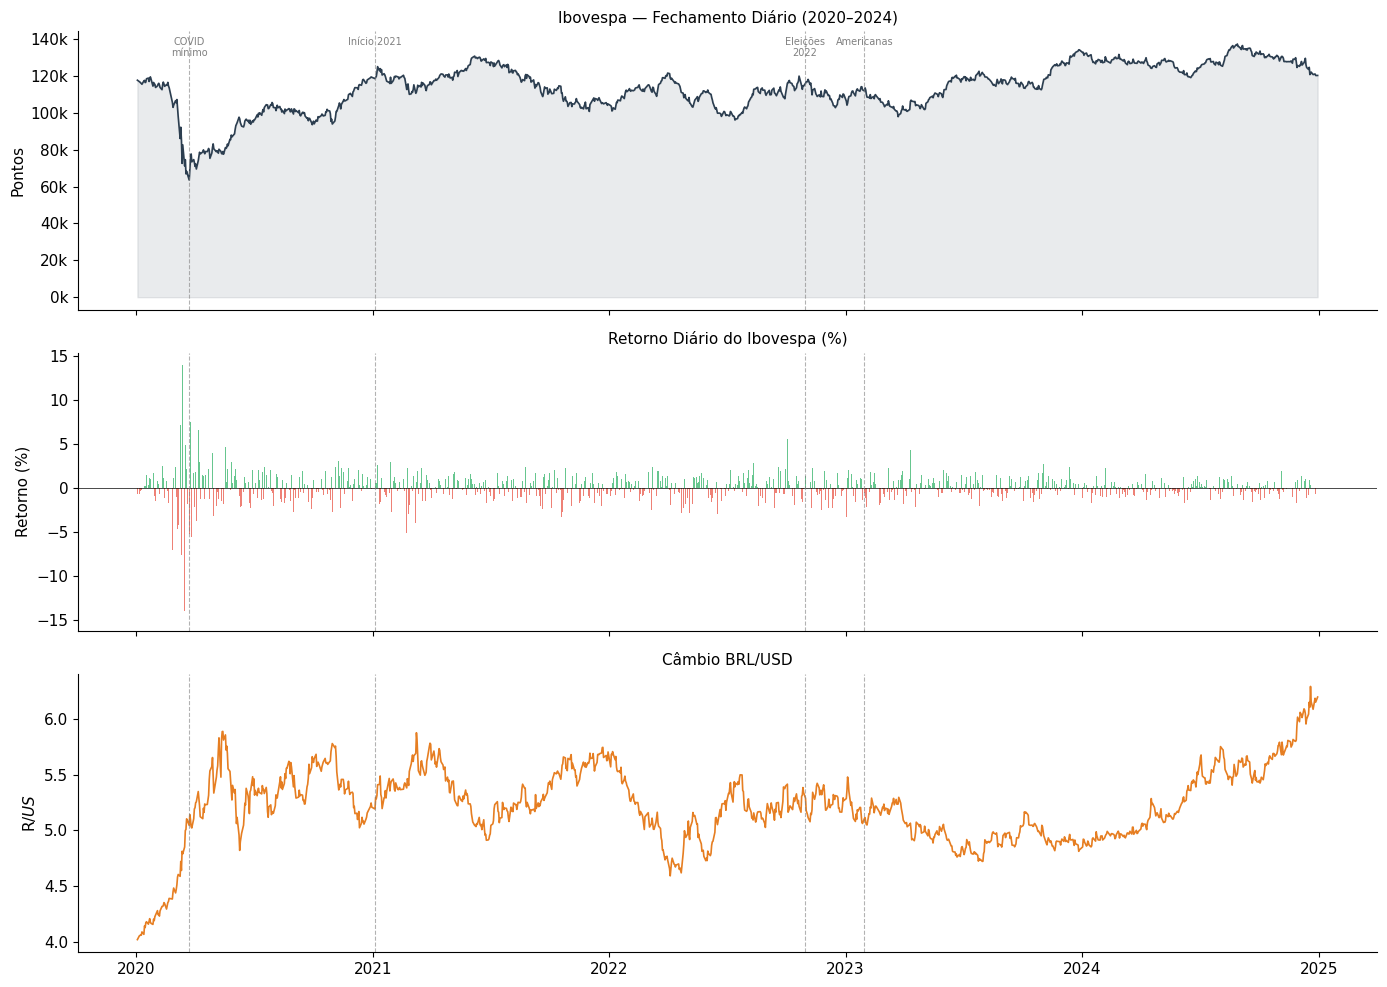

✅ Figura salva: dados_tcc/fig3_series_mercado.png


In [41]:
# VISUALIZAÇÃO 3 — Séries de mercado

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Painel 1: Ibovespa
axes[0].plot(df_mercado.index, df_mercado['ibovespa_fechamento'], color='#2c3e50', linewidth=1.2)
axes[0].fill_between(df_mercado.index, df_mercado['ibovespa_fechamento'],
                     alpha=0.1, color='#2c3e50')
axes[0].set_ylabel('Pontos')
axes[0].set_title('Ibovespa — Fechamento Diário (2020–2024)', fontsize=11)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# Painel 2: Retorno diário
cores_ret = ['#e74c3c' if r < 0 else '#27ae60' for r in df_mercado['retorno_ibov']]
axes[1].bar(df_mercado.index, df_mercado['retorno_ibov'], color=cores_ret,
            width=1, alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_ylabel('Retorno (%)')
axes[1].set_title('Retorno Diário do Ibovespa (%)', fontsize=11)

# Painel 3: Câmbio BRL/USD
axes[2].plot(df_mercado.index, df_mercado['cambio_brlusd'], color='#e67e22', linewidth=1.2)
axes[2].set_ylabel('R$/US$')
axes[2].set_title('Câmbio BRL/USD', fontsize=11)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[2].xaxis.set_major_locator(mdates.YearLocator())

# Marcadores de eventos relevantes
eventos = {
    '2020-03-23': 'COVID\nmínimo',
    '2021-01-04': 'Início 2021',
    '2022-10-30': 'Eleições\n2022',
    '2023-01-30': 'Americanas'
}
for data_str, label in eventos.items():
    try:
        data_ev = pd.Timestamp(data_str)
        if df_mercado.index.min() <= data_ev <= df_mercado.index.max():
            for ax in axes:
                ax.axvline(data_ev, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
            axes[0].text(data_ev, axes[0].get_ylim()[1] * 0.98, label,
                         fontsize=7, color='gray', ha='center', va='top')
    except:
        pass

plt.tight_layout()
plt.savefig('dados_tcc/fig3_series_mercado.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figura salva: dados_tcc/fig3_series_mercado.png')

In [42]:
# Salva os dados de mercado
df_mercado.to_csv('dados_tcc/dados_mercado_2020_2024.csv')
print(f'✅ Dados de mercado salvos: dados_tcc/dados_mercado_2020_2024.csv ({len(df_mercado):,} linhas)')

✅ Dados de mercado salvos: dados_tcc/dados_mercado_2020_2024.csv (1,243 linhas)


---
## 🔍 BLOCO 4 — Google Trends: Interesse de Busca por Termos Financeiros

O Google Trends fornece uma proxy do interesse/atenção do investidor, funcionando como variável complementar no índice de sentimento.

> **Nota:** A API do Google Trends tem limitações de taxa (erro 429). O código já inclui pausas automáticas e tratamento de erros por grupo.

In [43]:
from pytrends.request import TrendReq
import time

# Termos financeiros brasileiros — divididos em grupos de até 5 (limite do Google Trends)
GRUPOS_TERMOS = [
    ['Ibovespa', 'renda variável', 'bolsa de valores', 'B3', 'ações'],
    ['crise econômica', 'inflação', 'dólar hoje', 'Selic', 'juros'],
    ['Bitcoin', 'investimento', 'Copom', 'recessão', 'CDI']
]

pytrends = TrendReq(hl='pt-BR', tz=180)
frames_trends = []

print('⏳ Coletando Google Trends (Brasil, 2020–2024)...')
print(' (Pausas automáticas entre grupos para respeitar limites da API)\n')

for i, grupo in enumerate(GRUPOS_TERMOS):
    print(f'  Grupo {i+1}/3: {grupo}')
    try:
        pytrends.build_payload(
            grupo,
            timeframe='2020-01-01 2024-12-31',
            geo='BR'
        )
        df_grupo = pytrends.interest_over_time()
        if not df_grupo.empty:
            df_grupo = df_grupo.drop(columns=['isPartial'], errors='ignore')
            frames_trends.append(df_grupo)
            print(f'  ✅ {len(df_grupo)} semanas coletadas')
        else:
            print(f'  ⚠️ Sem dados para este grupo')
    except Exception as e:
        print(f'  ⚠️ Erro (grupo {i+1}): {e} — pulando para o próximo')

    if i < len(GRUPOS_TERMOS) - 1:
        print('  ⏱️ Aguardando 10s...')
        time.sleep(10)  # pausa aumentada para reduzir chances de bloqueio

print('\n✅ Coleta de Google Trends concluída!')

⏳ Coletando Google Trends (Brasil, 2020–2024)...
 (Pausas automáticas entre grupos para respeitar limites da API)

  Grupo 1/3: ['Ibovespa', 'renda variável', 'bolsa de valores', 'B3', 'ações']
  ✅ 262 semanas coletadas
  ⏱️ Aguardando 10s...
  Grupo 2/3: ['crise econômica', 'inflação', 'dólar hoje', 'Selic', 'juros']
  ✅ 262 semanas coletadas
  ⏱️ Aguardando 10s...
  Grupo 3/3: ['Bitcoin', 'investimento', 'Copom', 'recessão', 'CDI']
  ✅ 262 semanas coletadas

✅ Coleta de Google Trends concluída!


In [44]:
# Consolida todos os grupos de trends

if frames_trends:
    df_trends = pd.concat(frames_trends, axis=1)
    df_trends.index = pd.to_datetime(df_trends.index)
    df_trends.index = df_trends.index.tz_localize(None)

    # Remove colunas duplicadas
    df_trends = df_trends.loc[:, ~df_trends.columns.duplicated()]

    print(f'✅ Google Trends consolidado!')
    print(f'Período: {df_trends.index.min().date()} a {df_trends.index.max().date()}')
    print(f'Semanas: {len(df_trends):,} | Termos: {len(df_trends.columns)}')
    print(f'Termos coletados: {list(df_trends.columns)}')
    df_trends.head(3)
else:
    print('⚠️ Nenhum dado de Trends foi coletado. Verifique sua conexão.')
    df_trends = pd.DataFrame()

✅ Google Trends consolidado!
Período: 2019-12-29 a 2024-12-29
Semanas: 262 | Termos: 15
Termos coletados: ['Ibovespa', 'renda variável', 'bolsa de valores', 'B3', 'ações', 'crise econômica', 'inflação', 'dólar hoje', 'Selic', 'juros', 'Bitcoin', 'investimento', 'Copom', 'recessão', 'CDI']


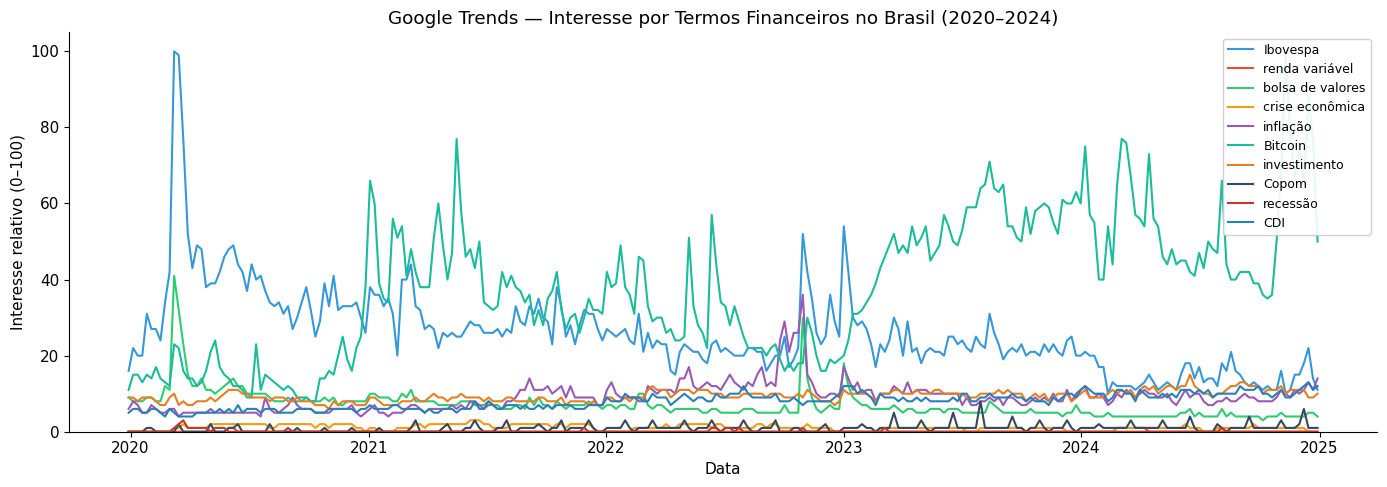

✅ Figura salva: dados_tcc/fig4_google_trends.png


In [45]:
# VISUALIZAÇÃO 4 — Google Trends para termos financeiros selecionados

if not df_trends.empty:
    termos_plot = ['Ibovespa', 'renda variável', 'bolsa de valores', 'crise econômica', 'inflação',
                   'Bitcoin', 'investimento', 'Copom', 'recessão', 'CDI']
    termos_disponiveis = [t for t in termos_plot if t in df_trends.columns]

    if not termos_disponiveis:
        termos_disponiveis = list(df_trends.columns[:5])

    fig, ax = plt.subplots(figsize=(14, 5))

    cores_trends = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6',
                    '#1abc9c', '#e67e22', '#34495e', '#c0392b', '#2980b9']
    for termo, cor in zip(termos_disponiveis, cores_trends):
        ax.plot(df_trends.index, df_trends[termo], label=termo, color=cor, linewidth=1.5)

    ax.set_xlabel('Data')
    ax.set_ylabel('Interesse relativo (0–100)')
    ax.set_title('Google Trends — Interesse por Termos Financeiros no Brasil (2020–2024)')
    ax.legend(loc='upper right', framealpha=0.9, fontsize=9)
    ax.set_ylim(0, 105)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())

    plt.tight_layout()
    plt.savefig('dados_tcc/fig4_google_trends.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Figura salva: dados_tcc/fig4_google_trends.png')
else:
    print('⚠️ Dados de Trends não disponíveis para plotagem')

In [46]:
# Reamostra Trends de semanal para diário (interpolação linear)
# Necessário para alinhar com os dados diários do Ibovespa na Fase 3

if not df_trends.empty:
    idx_diario = pd.date_range(start=DATA_INICIO, end=DATA_FIM, freq='D')
    df_trends_diario = df_trends.reindex(df_trends.index.union(idx_diario))
    df_trends_diario = df_trends_diario.interpolate(method='linear')
    df_trends_diario = df_trends_diario.reindex(idx_diario)

    df_trends_diario.to_csv('dados_tcc/google_trends_diario.csv')
    print(f'✅ Google Trends (diário, interpolado) salvo: {len(df_trends_diario):,} linhas')
else:
    print('⚠️ Pulando: sem dados de Trends para salvar')

✅ Google Trends (diário, interpolado) salvo: 1,827 linhas


---
## 📋 BLOCO 5 — Sumário Final da Fase 1

In [47]:
# RELATÓRIO FINAL DA FASE 1

print('=' * 60)
print(' ✅ FASE 1 CONCLUÍDA — SUMÁRIO DOS DADOS COLETADOS')
print('=' * 60)

print(f'''
📚 1. DATASET DE SENTIMENTO (FinBERT-PT-BR)
   Fonte: lucas-leme/Sentiments-FinBERT-PT-BR (HuggingFace)
   Registros: {len(df_sentimento):,} textos anotados em português
   Classes: Positivo / Neutro / Negativo / Não se aplica
   Arquivo: dados_tcc/dataset_sentimento_ptbr.csv

📈 2. DADOS DE MERCADO
   Fonte: Yahoo Finance + API Banco Central do Brasil
   Período: {DATA_INICIO} a {DATA_FIM}
   Observações: {len(df_mercado):,} dias de pregão
   Variáveis: Ibovespa, Câmbio BRL/USD, VIX{', Selic' if selic_ok else ''}
   Arquivo: dados_tcc/dados_mercado_2020_2024.csv

🔍 3. GOOGLE TRENDS
   Fonte: Google Trends via pytrends
   Termos: {len(df_trends.columns) if not df_trends.empty else 0} termos financeiros brasileiros
   Resolução: Semanal → interpolado para diário
   Arquivo: dados_tcc/google_trends_diario.csv

🖼️ 4. FIGURAS GERADAS
   fig1_distribuicao_sentimentos.png
   fig2_tamanho_textos.png
   fig3_series_mercado.png
   fig4_google_trends.png
''')

print('=' * 60)
print(' PRÓXIMO PASSO: FASE 2 — Modelagem de Sentimento')
print(' → Carregar FinBERT-PT-BR e classificar notícias')
print(' → Calcular IS(d) — Índice diário de sentimento')
print(' → Avaliar com F1-score e Kappa de Cohen')
print('=' * 60)

 ✅ FASE 1 CONCLUÍDA — SUMÁRIO DOS DADOS COLETADOS

📚 1. DATASET DE SENTIMENTO (FinBERT-PT-BR)
   Fonte: lucas-leme/Sentiments-FinBERT-PT-BR (HuggingFace)
   Registros: 661 textos anotados em português
   Classes: Positivo / Neutro / Negativo / Não se aplica
   Arquivo: dados_tcc/dataset_sentimento_ptbr.csv

📈 2. DADOS DE MERCADO
   Fonte: Yahoo Finance + API Banco Central do Brasil
   Período: 2020-01-01 a 2024-12-31
   Observações: 1,243 dias de pregão
   Variáveis: Ibovespa, Câmbio BRL/USD, VIX, Selic
   Arquivo: dados_tcc/dados_mercado_2020_2024.csv

🔍 3. GOOGLE TRENDS
   Fonte: Google Trends via pytrends
   Termos: 15 termos financeiros brasileiros
   Resolução: Semanal → interpolado para diário
   Arquivo: dados_tcc/google_trends_diario.csv

🖼️ 4. FIGURAS GERADAS
   fig1_distribuicao_sentimentos.png
   fig2_tamanho_textos.png
   fig3_series_mercado.png
   fig4_google_trends.png

 PRÓXIMO PASSO: FASE 2 — Modelagem de Sentimento
 → Carregar FinBERT-PT-BR e classificar notícias
 → Ca

In [48]:
# Lista todos os arquivos gerados
import os

print('📁 Arquivos gerados em dados_tcc/:')
for f in sorted(os.listdir('dados_tcc')):
    tamanho = os.path.getsize(f'dados_tcc/{f}')
    if tamanho > 1024:
        print(f'  {f} ({tamanho/1024:.1f} KB)')
    else:
        print(f'  {f} ({tamanho} B)')

📁 Arquivos gerados em dados_tcc/:
  dados_mercado_2020_2024.csv (125.8 KB)
  dataset_sentimento_ptbr.csv (155.8 KB)
  fig1_distribuicao_sentimentos.png (81.6 KB)
  fig2_tamanho_textos.png (58.3 KB)
  fig3_series_mercado.png (208.9 KB)
  fig4_google_trends.png (292.6 KB)
  google_trends_diario.csv (320.2 KB)


In [49]:
import shutil, os

# Copia todos os arquivos da sessão para o Drive
src = 'dados_tcc'
dst = '/content/drive/MyDrive/TCC_dados'
for f in os.listdir(src):
    shutil.copy(os.path.join(src, f), dst)
print('✅ Arquivos copiados para o Google Drive!')

✅ Arquivos copiados para o Google Drive!
